In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings

In [4]:
warnings.filterwarnings("ignore")

In [6]:
ipl = pd.read_csv('data (2).csv')
ipl

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76009,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,121,7,19.2,40,0,40,12,129
76010,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,127,7,19.3,46,0,46,12,129
76011,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,128,7,19.4,47,0,47,12,129
76012,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian,129,7,19.5,48,0,47,13,129


In [7]:

df = ipl.drop(['date', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'mid', 'striker', 'non-striker'], axis=1)

In [8]:
df

,venue,bat_team,bowl_team,batsman,bowler,total
0,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,222
1,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,222
2,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,222
3,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,222
4,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,222
...,...,...,...,...,...,...
76009,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,129
76010,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,129
76011,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,129
76012,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian,129


In [9]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns

['total']

In [10]:
X = df.drop(['total'], axis=1)
y = df['total']

In [11]:
X

,venue,bat_team,bowl_team,batsman,bowler
0,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar
1,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar
2,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar
3,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar
4,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar
...,...,...,...,...,...
76009,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian
76010,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian
76011,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian
76012,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian


In [12]:
y

0        222
1        222
2        222
3        222
4        222
        ... 
76009    129
76010    129
76011    129
76012    129
76013    129
Name: total, Length: 76014, dtype: int64

In [13]:

plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

Text(0, 0.5, 'Count')

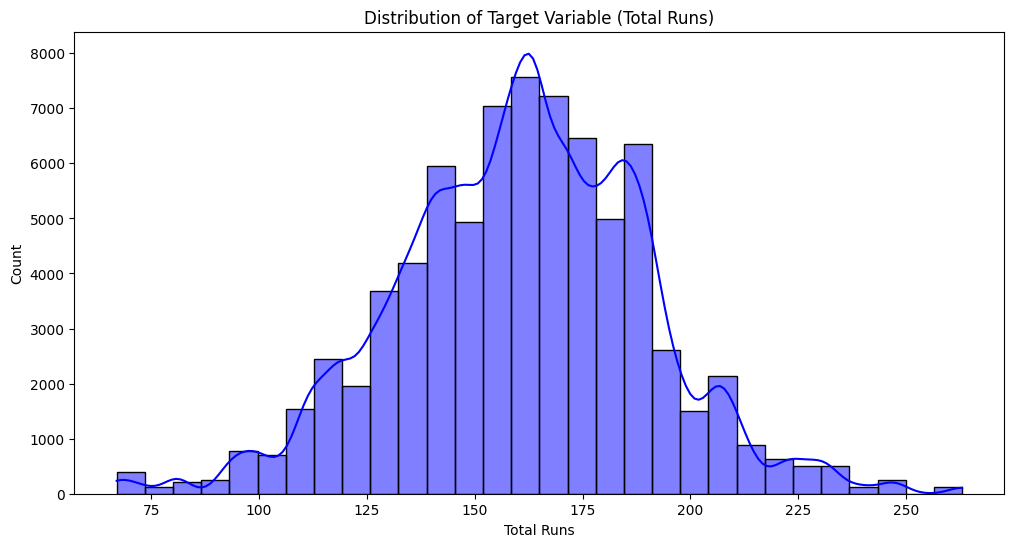

In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(y, bins=30, kde=True, color='blue')
plt.title('Distribution of Target Variable (Total Runs)')
plt.xlabel('Total Runs')
plt.ylabel('Count')

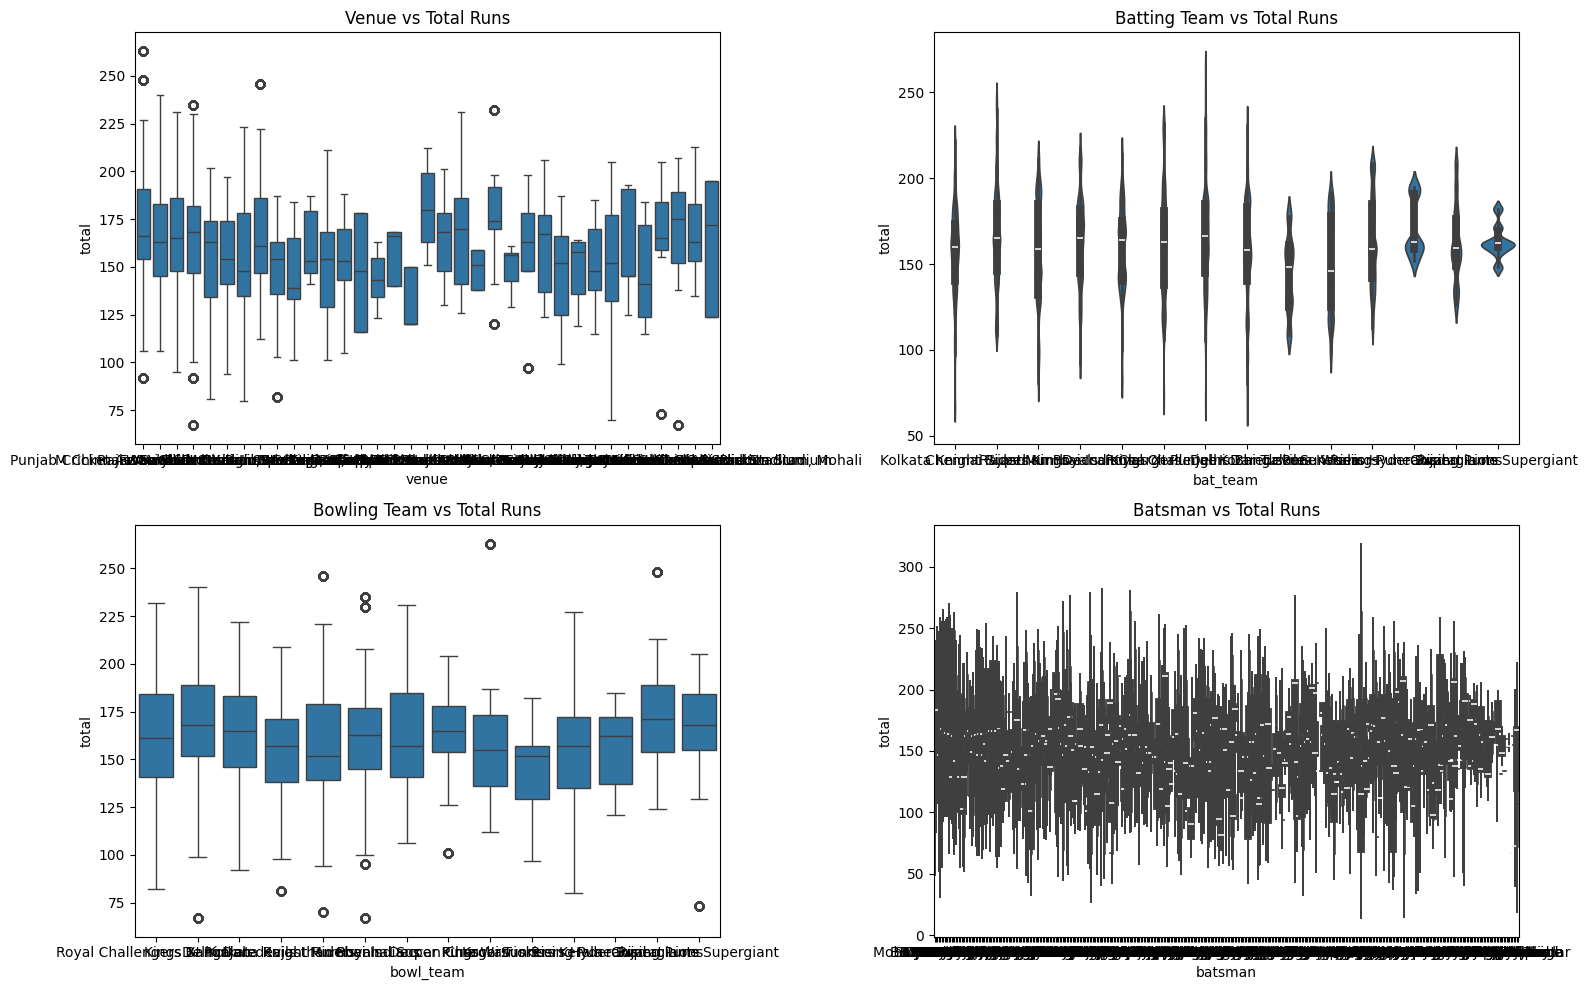

In [15]:
plt.figure(figsize=(16, 10))
plt.subplot(2, 2, 1)
sns.boxplot(x='venue', y='total', data=df)
plt.title('Venue vs Total Runs')

plt.subplot(2, 2, 2)
sns.violinplot(x='bat_team', y='total', data=df)
plt.title('Batting Team vs Total Runs')

plt.subplot(2, 2, 3)
sns.boxplot(x='bowl_team', y='total', data=df)
plt.title('Bowling Team vs Total Runs')

plt.subplot(2, 2, 4)
sns.violinplot(x='batsman', y='total', data=df)
plt.title('Batsman vs Total Runs')

plt.tight_layout()

In [16]:
venue_encoder = LabelEncoder()
batting_team_encoder = LabelEncoder()
bowling_team_encoder = LabelEncoder()
striker_encoder = LabelEncoder()
bowler_encoder = LabelEncoder()

In [17]:
venue_encoder

LabelEncoder()

In [18]:
batting_team_encoder

LabelEncoder()

In [19]:
X['venue'] = venue_encoder.fit_transform(X['venue'])
X['bat_team'] = batting_team_encoder.fit_transform(X['bat_team'])
X['bowl_team'] = bowling_team_encoder.fit_transform(X['bowl_team'])
X['batsman'] = striker_encoder.fit_transform(X['batsman'])
X['bowler'] = bowler_encoder.fit_transform(X['bowler'])

In [20]:
X['venue']

0        14
1        14
2        14
3        14
4        14
         ..
76009    23
76010    23
76011    23
76012    23
76013    23
Name: venue, Length: 76014, dtype: int64

In [21]:
X['bowl_team']

0        12
1        12
2        12
3        12
4        12
         ..
76009    10
76010    10
76011    10
76012    10
76013    10
Name: bowl_team, Length: 76014, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
X_train

,venue,bat_team,bowl_team,batsman,bowler
31043,15,12,0,78,121
1720,22,2,4,393,48
62369,14,12,13,384,175
74763,21,4,6,398,157
10506,2,7,2,266,218
...,...,...,...,...,...
37194,34,6,7,221,272
6265,26,7,9,347,292
54886,1,7,0,213,183
860,15,0,7,258,275


In [24]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
X_train_scaled

array([[0.44117647, 0.92307692, 0.        , 0.1902439 , 0.36890244],
       [0.64705882, 0.15384615, 0.30769231, 0.95853659, 0.14634146],
       [0.41176471, 0.92307692, 1.        , 0.93658537, 0.53353659],
       ...,
       [0.02941176, 0.53846154, 0.        , 0.5195122 , 0.55792683],
       [0.44117647, 0.        , 0.53846154, 0.62926829, 0.83841463],
       [0.41176471, 0.92307692, 0.        , 0.93658537, 0.5152439 ]],
      shape=(53209, 5))

In [27]:
scaler

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [29]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()  
model.fit(X_train_scaled, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Step 1: Define the model
model = RandomForestRegressor()

# Step 2: Train the model
model.fit(X_train_scaled, y_train)

# Step 3: Predict
predictions = model.predict(X_test_scaled)

# Step 4: Evaluate
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Step 5: Show metrics
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2 Score: {r2}")


MAE: 2.1300584545969934
MSE: 54.17654468612693
R2 Score: 0.9357628692506813


MAE: 2.13
MSE: 54.18
R2 Score: 0.94


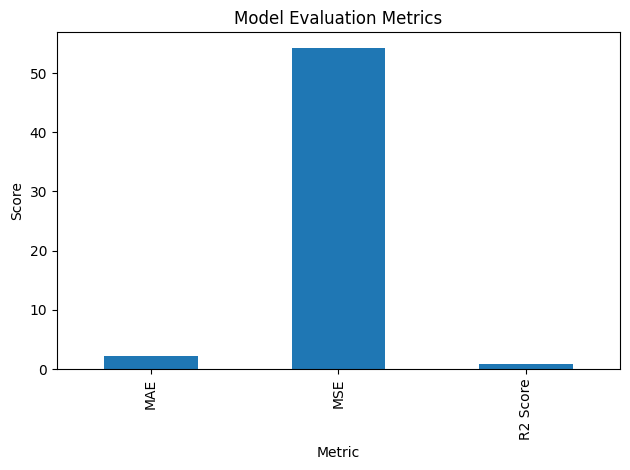

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Predict
predictions = model.predict(X_test_scaled)

# Step 2: Evaluate
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Step 3: Display metrics
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Step 4: Optional plot
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "R2 Score"],
    "Value": [mae, mse, r2]
})

metrics_df.set_index("Metric").plot(kind="bar", legend=False, title="Model Evaluation Metrics")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

